## ДЗ №1. Метрики и простейшие алгоритмы рекомендаций

## Общая информация
**Дата выдачи: 4 февраля 2025**

**Дедлайн: 12 февраля 2025 23:59 MSK**

In [35]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from tqdm.auto import tqdm
from typing import List, Optional
from metric_tests import run_tests

%matplotlib inline

## О задании

В этой работе мы посмотрим на то, как работают самые простые модели для рекомендаций. Как правило, они не требуют построения специальных моделей, но даже так оказываются полезны в качестве бейзлайна. Попробуем сделать предсказания с помощью EASE. Это тоже довольно простой подход, но не стоит забывать, что сложные модели могут оказаться не лучшим выбором в условиях большого количества данных. Посчитаем метрики, построим графики и подумаем, насколько хорошо эти модели вообще решают поставленную задачу.

Мы будем работать с датасетом по рекомендации фильмов от Kion MTS, который был дан для соревнования. Сперва нужно его предобработать, эта часть повторяет то, что было на семинаре. 

Датасет необходимо скачать: https://ods.ai/competitions/competition-recsys-21/data

Оттуда нужны файлы `interactions.csv` и `items.csv`

Каждое задание весит **1 балл**, если выполнено полностью и без ошибок, **0 баллов** ставится при наличии хотя бы 1 ошибки. Максимальная оценка - **10 баллов**. Шаблоны функций и классов можно менять по своему усмотрению.

In [36]:
df = pd.read_csv('interactions.csv').iloc[:-1]
df.head()   

,user_id,item_id,last_watch_dt,total_dur,watched_pct
0,176549,9506,2021-05-11,4250,72.0
1,699317,1659,2021-05-29,8317,100.0
2,656683,7107,2021-05-09,10,0.0
3,864613,7638,2021-07-05,14483,100.0
4,964868,9506,2021-04-30,6725,100.0


In [37]:
df['last_watch_dt'] = (pd.to_datetime(df['last_watch_dt']) - pd.to_datetime(df['last_watch_dt']).min())
df['last_watch_dt'] = df.last_watch_dt.apply(lambda x: int(str(x).split()[0]))
df.sample(5)

,user_id,item_id,last_watch_dt,total_dur,watched_pct
3739457,576537,11985,79,4554,79.0
2900629,197179,9728,104,20,0.0
5001659,781277,4116,84,9309,100.0
1949270,449035,4880,107,3,0.0
668494,233311,6208,66,5,0.0


Сделаем разбиение по времени

<Axes: >

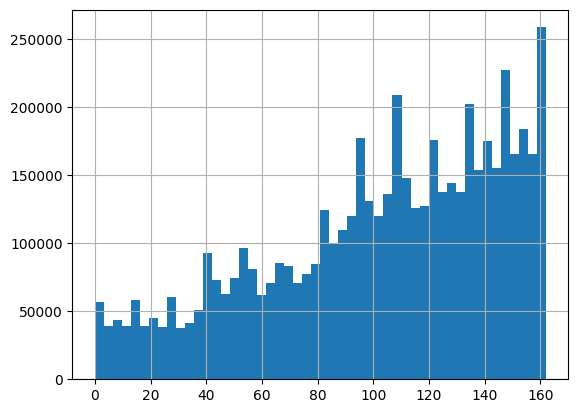

In [38]:
df.last_watch_dt.hist(bins=50)

In [39]:
train_df = df.loc[(df.last_watch_dt < 160-7)].copy()
test_df = df.loc[(df.last_watch_dt >= 160-7)].copy()

train_users = train_df.user_id.unique()
test_users = test_df.user_id.unique()

all_included = np.intersect1d(train_users, test_users)

print('число людей и там и там: ', all_included.shape[0])
print('число людей всего:', train_users.shape[0])

число людей и там и там:  134670
число людей всего: 880449


In [41]:
len(set(test_users) - set(train_users)) / len(test_users)

0.37768022181146027

И переведём всё к соединённому датасету:

In [43]:
n_users = 10000

all_included = np.random.choice(all_included, size=n_users, replace=False)

train_df = train_df.loc[train_df.user_id.isin(all_included)].copy()
test_df = test_df.loc[test_df.user_id.isin(all_included)].copy()

assert train_df.last_watch_dt.max() < test_df.last_watch_dt.min()
assert train_df.user_id.nunique() == n_users
assert test_df.user_id.nunique() == n_users

In [45]:
train_df.head()

,user_id,item_id,last_watch_dt,total_dur,watched_pct
20,896751,8081,65,6358,100.0
109,614119,14362,92,5074,94.0
114,806082,579,110,836,11.0
123,514235,8391,147,3570,57.0
127,375013,6907,104,8079,100.0


In [47]:
train_grouped = train_df.groupby('user_id').apply(
    lambda x: [(t1, t2) for t1, t2 in sorted(zip(x.item_id,
                                                 x.last_watch_dt), key=lambda x: x[1])]
).reset_index()
train_grouped.rename({0:'train_interactions'}, axis=1, inplace=True)

test_grouped = test_df.groupby('user_id').apply(
    lambda x: [(t1, t2) for t1, t2 in sorted(zip(x.item_id,
                                                         x.last_watch_dt), key=lambda x: x[1])]
).reset_index()
test_grouped.rename({0:'test_interactions'}, axis=1, inplace=True)

train_grouped.head()

,user_id,train_interactions
0,106,"[(9335, 28), (312, 35), (11494, 35), (12965, 5..."
1,241,"[(5051, 9), (2134, 9), (13913, 112), (6646, 11..."
2,322,"[(4549, 94), (8419, 94), (14814, 94), (10219, ..."
3,400,"[(169, 144), (11047, 145), (12974, 145), (1399..."
4,446,"[(13865, 105)]"


In [49]:
joined = train_grouped.merge(test_grouped)
joined.head()

,user_id,train_interactions,test_interactions
0,106,"[(9335, 28), (312, 35), (11494, 35), (12965, 5...","[(12908, 159), (2836, 159), (12873, 159), (337..."
1,241,"[(5051, 9), (2134, 9), (13913, 112), (6646, 11...","[(6162, 156), (10440, 156), (8986, 156), (1213..."
2,322,"[(4549, 94), (8419, 94), (14814, 94), (10219, ...","[(4651, 155), (15384, 155), (11099, 157), (633..."
3,400,"[(169, 144), (11047, 145), (12974, 145), (1399...","[(7793, 153)]"
4,446,"[(13865, 105)]","[(12202, 160), (230, 160)]"


In [51]:
np.random.seed(777)

class Random:

    def __init__(self):

        self.trained = False

    def fit(self, df, col='train_interactions'):

        items = set()
        for _, row in df.iterrows():
            for item, _ in row[col]:
                items.add(item)

        self.items = list(items)
        self.trained = True

    def predict(self, df, topn=10):
        assert self.trained
        return [np.random.choice(self.items, replace=False, size=topn)]*len(df)


random = Random()
random.fit(joined)

joined['random_recs'] = random.predict(joined, topn=3)
joined.head()

,user_id,train_interactions,test_interactions,random_recs
0,106,"[(9335, 28), (312, 35), (11494, 35), (12965, 5...","[(12908, 159), (2836, 159), (12873, 159), (337...","[6138, 3732, 1029]"
1,241,"[(5051, 9), (2134, 9), (13913, 112), (6646, 11...","[(6162, 156), (10440, 156), (8986, 156), (1213...","[6138, 3732, 1029]"
2,322,"[(4549, 94), (8419, 94), (14814, 94), (10219, ...","[(4651, 155), (15384, 155), (11099, 157), (633...","[6138, 3732, 1029]"
3,400,"[(169, 144), (11047, 145), (12974, 145), (1399...","[(7793, 153)]","[6138, 3732, 1029]"
4,446,"[(13865, 105)]","[(12202, 160), (230, 160)]","[6138, 3732, 1029]"


**Задание №1. Метрики и бейзлайны**

Добавьте реализацию метрик AP, RR, HR, их усреднённые версии по $U$ мы посчитаем ниже, если следовать коду с семинара, поэтому формулы немного отличаются. За имплементацию с циклами балл будет снижаться, векторизуйте! ( ͡° ͜ʖ ͡°)

$$
AP_u@k = \frac{1}{\min(k, n_u)} \sum_{i=1}^k r_u(i) p_u@i
$$
$$
p_u@k = \dfrac{1}{k}\sum_{j=1}^k r_u(j)
$$
$$
RR@k = \dfrac{1}{\text{rank}_i@k}
$$
$$
HR@k = [\exists \ y_i = 1 \ \text{among k preds}]
$$


*   $n_u$ - число айтемов, с которыми взаимодействовал юзер $u$
*   $y_i$ - релевантно ли $i$-ое предсказание, $y_i \in \{0,1\}$
* $\text{rank}_i@k$ - позиция первого релеваннтого айтема среди первых $k$ предсказаний
* HR@k - среди первых $k$ предсказаний есть хотя бы одно релевантное

Считайте, что если `topn` не задано, то берётся всегда $n_u$. 

In [ ]:
from numpy import intersect1d


def ap_metric(
    gt_items: List[int],
    predictions: List[int],
    topn: Optional[int]=None
):
    if topn is None:
        topn = len(predictions)
    ap = 0
    find_nice_ans = 0
    for i in range(topn):
        if predictions[i] in gt_items:
            find_nice_ans += 1
            ap += find_nice_ans / (i + 1)
    ap /= min(topn, len(gt_items))
    return ap

def rr_metric(
    gt_items: List[int],
    predictions: List[int],
    topn: Optional[int]=None
):
    if topn is None:
        topn = len(predictions)
    rr = 0
    for i in range(topn):
        if predictions[i] in gt_items:
            rr = 1 / (i + 1)
            break
    return rr

def hr_metric(
    gt_items: List[int],
    predictions: List[int],
    topn: Optional[int]=None
):
    if topn is None:
        topn = len(predictions)
    if len(np.intersect1d(gt_items, predictions[:topn])) != 0:
        return 1
    return 0


Для вашего удобства в файле `metric_tests.py` есть тесты, но хардкодить их, разумеется, не стоит. 

In [55]:
run_tests(ap_metric, rr_metric, hr_metric)

В следующей ячейке код, который считает и усредняет метрики по юзерам. Он взят с семинара, при желании можно его тоже модифицировать, например, векторизовать. 

In [57]:
def evaluate_recommender(df, model_preds, gt_col='test_interactions', k=None):

    metric_values = []

    for idx, row in df.iterrows():
        gt_items = [x[0] for x in row[gt_col]]
        predictions = row[model_preds]

        ap = ap_metric(gt_items, predictions, k)
        rr = rr_metric(gt_items, predictions, k)
        hr = hr_metric(gt_items, predictions, k)

        metric_values.append((ap, rr, hr))

    return {'map': np.mean([x[0] for x in metric_values]),
            'mrr': np.mean([x[1] for x in metric_values]),
            'hr': np.mean([x[2] for x in metric_values])}

Если вы всё сделали правильно, рандомные предсказания должны дать хоть какое-то качество, но не очень большое.

In [59]:
evaluate_recommender(joined, model_preds='random_recs')

{'map': np.float64(6.666666666666666e-05),
 'mrr': np.float64(0.0002),
 'hr': np.float64(0.0002)}

In [61]:
class TopPopular:

    def __init__(self):

        self.trained = False

    def fit(self, df, col='train_interactions'):

        counts = {}
        for _, row in df.iterrows():
            for item, _ in row[col]:
                if item in counts:
                    counts[item] += 1
                else:
                    counts[item] = 1

        counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)

        self.recommenations = [x[0] for x in counts]
        self.trained = True

    def predict(self, df, topn=10)  -> List[np.ndarray]:

        assert self.trained
        return [self.recommenations[:topn]]*len(df)


toppop = TopPopular()
toppop.fit(joined)

joined['toppopular_recs'] = toppop.predict(joined)
joined.head()

,user_id,train_interactions,test_interactions,random_recs,toppopular_recs
0,106,"[(9335, 28), (312, 35), (11494, 35), (12965, 5...","[(12908, 159), (2836, 159), (12873, 159), (337...","[6138, 3732, 1029]","[10440, 15297, 9728, 13865, 3734, 4151, 4880, ..."
1,241,"[(5051, 9), (2134, 9), (13913, 112), (6646, 11...","[(6162, 156), (10440, 156), (8986, 156), (1213...","[6138, 3732, 1029]","[10440, 15297, 9728, 13865, 3734, 4151, 4880, ..."
2,322,"[(4549, 94), (8419, 94), (14814, 94), (10219, ...","[(4651, 155), (15384, 155), (11099, 157), (633...","[6138, 3732, 1029]","[10440, 15297, 9728, 13865, 3734, 4151, 4880, ..."
3,400,"[(169, 144), (11047, 145), (12974, 145), (1399...","[(7793, 153)]","[6138, 3732, 1029]","[10440, 15297, 9728, 13865, 3734, 4151, 4880, ..."
4,446,"[(13865, 105)]","[(12202, 160), (230, 160)]","[6138, 3732, 1029]","[10440, 15297, 9728, 13865, 3734, 4151, 4880, ..."


Самые популярные предсказания должны показать более высокое качество.

In [64]:
evaluate_recommender(joined, model_preds='toppopular_recs')

{'map': np.float64(0.06752417972096246),
 'mrr': np.float64(0.12055797619047619),
 'hr': np.float64(0.2984)}

**Задание №2. Рекомендации в окне**

Здесь необходимо переделать метод рекомендации по популярности так, что популярность считается только за какое-то более свежее временное окно. Под окном подразумевается какой-то временной промежуток, например, ближайший месяц. Соответственно, всё что за его пределами, не учитывается.

In [ ]:
from typing import override


class TopPopularWeighted(TopPopular):

    def __init__(self, min_window=2):
        super().__init__()
        self.min_window = min_window

    @override
    def fit(self, df: pd.DataFrame, col='train_interactions'):
        counts = {}
        max_time = 0
        for _, row in df.iterrows():
            for _, time in row[col]:
                max_time = max(max_time, time)
        for _, row in df.iterrows():
            for item, time in row[col]:
                if max_time - time <= self.min_window:
                    counts[item] = counts.get(item, 0) + 1
        counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)
        
        self.recommenations = [x[0] for x in counts]
        self.trained = True

Теперь постройте графики зависимости значений трёх метрик (AP@k, RR@k, HR@k) от размера окна. 

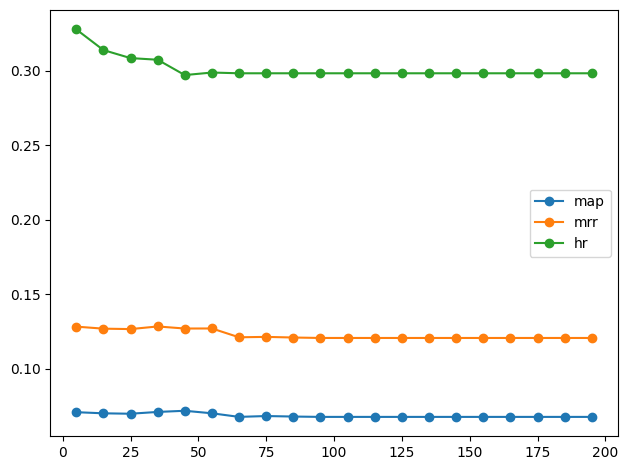

In [ ]:
from matplotlib.pyplot import plot

metrics_by_window = []
windows = np.arange(5, 200, 10)
for i in windows:
    toppop = TopPopularWeighted(min_window=int(i))
    toppop.fit(joined)
    joined['toppopular_recs'] = toppop.predict(joined)
    metrics_by_window.append(evaluate_recommender(joined, 'toppopular_recs'))

fig, ax = plt.subplots()
map_values = [i['map'] for i in metrics_by_window]
mrr_values = [i['mrr'] for i in metrics_by_window]
hr_values = [i['hr'] for i in metrics_by_window]

ax.plot(windows, map_values, label="map", marker='o')
ax.plot(windows, mrr_values, label="mrr", marker='o')
ax.plot(windows, hr_values, label="hr", marker='o')
ax.legend()
plt.tight_layout()
plt.show()

Подумайте и ответьте, как размер окна влияет на качество рекомендаций. Какое значение наилучшее, есть ли у этого разумное объяснение?

Как видно по метрикам, хоть и не значительно, но рекомендациям по самым популярным товаром только за последний месяц
дает лучший результат, чем за все время. И если мы хотим чтобы хотябы одна рекомендация оказалось правильной, выгодно брать как можно меньший промежуток времени для выбора популярных

**Задание №3. Метрики и k.**

Постройте зависимость значений MAP@K, MRR@K, HR@K для метода рекомендации по популярности. Возьмите какие-нибудь k, например, от 1 до 100, переберите значения и покажите на линейном графике. 

In [ ]:
joined['toppopular_recs'] = toppop.predict(joined, topn=100)

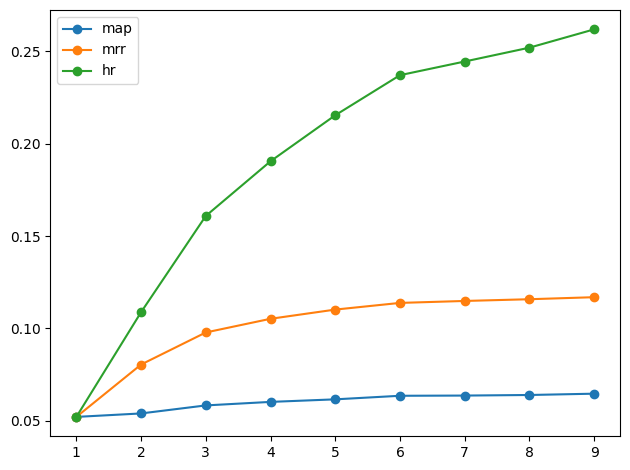

In [69]:
k_values = np.arange(1, 10, 1)
toppop = TopPopular()

metrics_by_window = []
for i in k_values:
    toppop = TopPopular()
    toppop.fit(joined)
    joined['toppopular_recs'] = toppop.predict(joined, topn=int(i))
    metrics_by_window.append(evaluate_recommender(joined, 'toppopular_recs'))

fig, ax = plt.subplots()
map_values = [i['map'] for i in metrics_by_window]
mrr_values = [i['mrr'] for i in metrics_by_window]
hr_values = [i['hr'] for i in metrics_by_window]

ax.plot(k_values, map_values, label="map", marker='o')
ax.plot(k_values, mrr_values, label="mrr", marker='o')
ax.plot(k_values, hr_values, label="hr", marker='o')
ax.legend()
plt.tight_layout()
plt.show()

Хорошенько подумайте и ответьте на вопросы ниже.

3.1 Какие из метрик являются монотонными функциями по top-K? Объясните, почему они являются монотонными? \

hr монотонно возрастает, так как количество юзеров в которых мы попали не может уменьшиться,\
mrr монотонно возрастает так как первый найденый подходящий фильм не будет меняться для уже положительных рекомендаций, где мы что то нашли \
map не факт что монотонно возрастает так как новых хороших рекомендаций мы можем не найти а поделить на большее k

3.2 Объясните по каждой метрике, как можно интерпретировать ее график? То есть, что можно сказать про связь изменения метрики c возможными пользовательскими сценариями, например,скроллингом ленты новостей. \

при скролинге видно что сначала hr растет быстро а потом медленее следовательно в начале шанс что очередная рекомендация
по итогу понравиться пользователю сначала более высокая\
mrr также показывает тоже самое что и hr mpp показывает что в среднем наши рекомендации становяться лучше но не значительно, так как упорядоченость рекомендаций не возникает, и правильные варианты оказываються ближе к концу.

3.3 Как вы думаете, почему графики выглядят именно так? Должны ли они возрастать/убывать, от чего это может зависеть? (Тут вам может помочь дополнительный анализ данных)\

график в общем возрастают так-как самые популярные фильмы в среднем смотрит много человек, и чем больше мы их предсказываем тем больше улучшаються все графики

**Задание №4. Интерпретация рейтингов**

Возьмите названия фильмов/сериалов из `items.csv`, выделите 5 различных сценариев изменения популярности у фильмов, аргументируйте (например, графиком или статистикой) и проинтерпретируейте их (почему популярность для этого фильма меняется так). Обратите внимание, что надо найти именно разные паттерны изменения вероятностей. 

In [70]:
items = pd.read_csv('items.csv')[['item_id','title']].copy()
items.head()

,item_id,title
0,10711,Поговори с ней
1,2508,Голые перцы
2,10716,Тактическая сила
3,7868,45 лет
4,16268,Все решает мгновение


Пример:

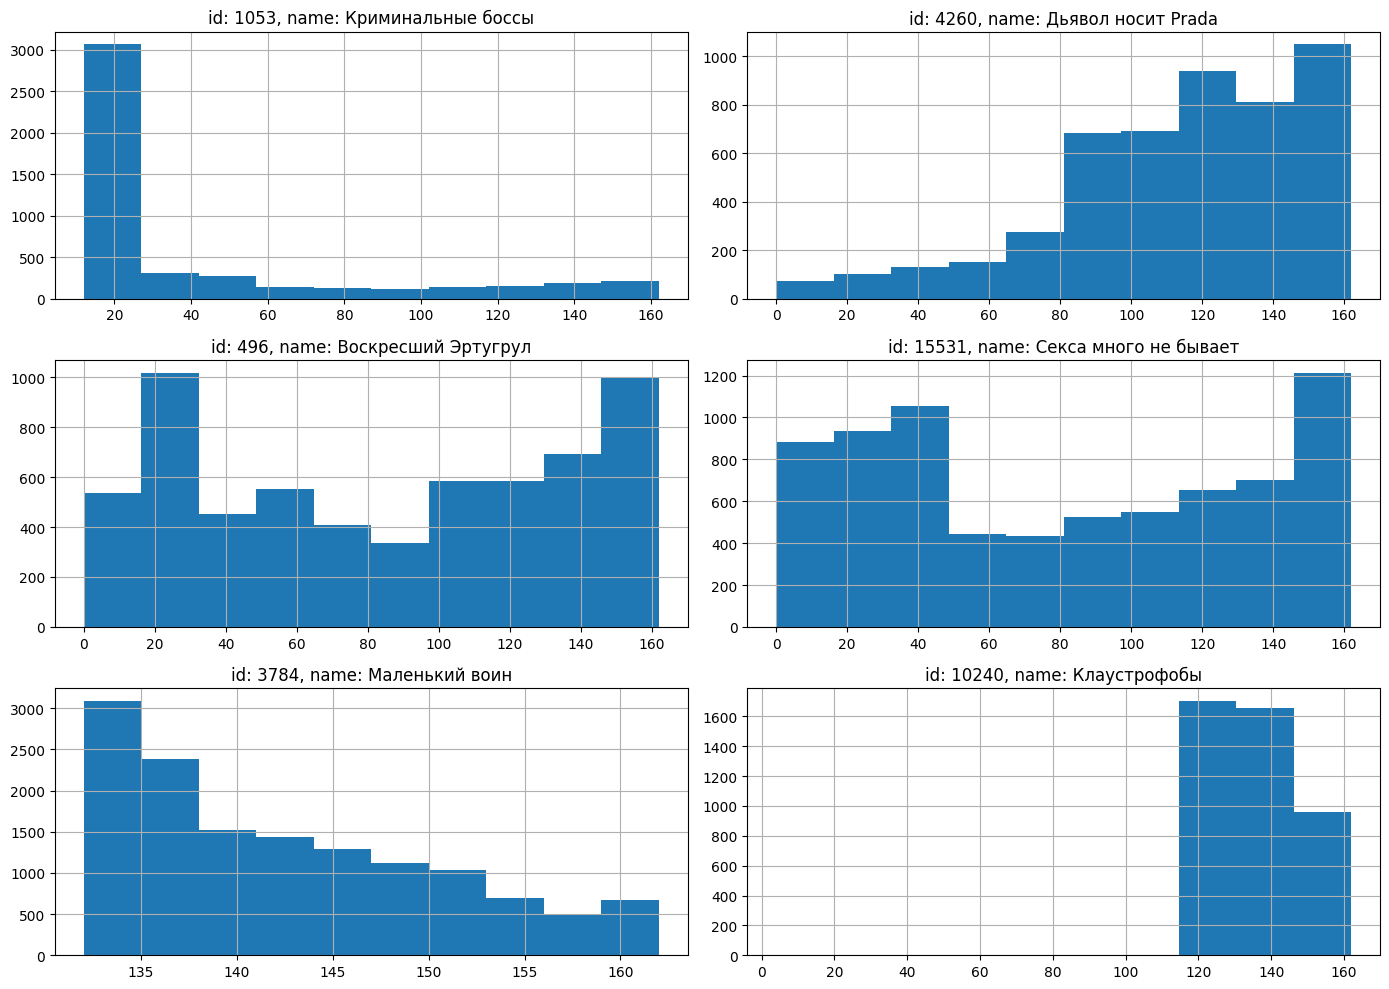

In [ ]:
import seaborn as sns

popular_items = df.item_id.value_counts()[:300].index.tolist()
n_samples = 6
unique_find_samples = [1053, 4260, 496, 15531, 3784, 10240]
hist_ax_names = ['a', 'b', 'c', 'd', 'e', 'f']
fig, ax = plt.subplot_mosaic([['a', 'b'], ['c', 'd'], ['e', 'f']], figsize=(14, 10))

for i in range(n_samples):
    sampled_id = np.random.choice(popular_items)
    if i < len(unique_find_samples):
        sampled_id = unique_find_samples[i]
    interactions = df.loc[df.item_id==sampled_id].copy()
    name = items.loc[items.item_id==sampled_id].title.values[0]
    interactions.last_watch_dt.hist(ax=ax[hist_ax_names[i]])
    ax[hist_ax_names[i]].set_title(f"id: {sampled_id}, name: {name}")
plt.tight_layout()
plt.show()

криминальные босы, резкая популярность в 1 дату, потом резкое падение, возможно новый блокбастер который, на который все сходили в кино, но он никому не понравился,

дьявол носит прада возрастающая популярность начиная с начала отсчета, возможно связано с анонсом / выходом новой части, или возможно где то был упомянут этот фильм.

Секса много не бывает, сначала небольшой рост потом падение, затем постепенный рост и через примерно 3 месяца возвращение популярности, возможно в это время фильм показывали в кинотеатрах, во время пиков.

Маленький воин, похоже что фильм вышел и медленно терял свою популярность со временем.

Клаустрофобы, только что вышли и популярны, не можем наблюдать за популярностью длительное время.

Воскресший Эртугрул, это сериал, возможно популярность сконцетрированая в 2 пиках связана с выходом последней / новой серии, новым сезоном.

искал примеры просто отрисовкой случайных фильмов и их популярностью

**Задание №5. User-item encoding**

Теперь, создайте матрицу интеракций user-item по примеру из семинара. Вам нужно в итоге получить разреженную матрицу (sparse matrix), в которой в качестве строк будут пользователи, в качестве колонок - айтемы. Не забудьте перекодировать пользователей и айтемы через энкодер. В отличие от семинара, оставьте в матрице только юзеров и айтемы, которые встречались в матрице > 4 раз.

Важно: когда вы отфильтруете юзеров на встречаемость > 4 раз, вы удалите какие-то айтемы, которые теперь станут встречаться меньше 5 раз. Поэтому у вас перестанет выполняться второе условие на минимальное число интеракций с айтемом. Тогда вам надо опять отфильтровать айтемы на встречаемость, но это снова может нарушить условие для юзеров. В таком случае, вам надо написать итеративный алгоритм до сходимости, пока требования не будут выполняться в обеих колонках. 

In [118]:
df

,user_id,item_id,last_watch_dt,total_dur,watched_pct
0,176549,9506,59,4250,72.0
1,699317,1659,77,8317,100.0
2,656683,7107,57,10,0.0
3,864613,7638,114,14483,100.0
4,964868,9506,48,6725,100.0
...,...,...,...,...,...
5476245,786732,4880,60,753,0.0
5476246,648596,12225,153,76,0.0
5476247,546862,9673,31,2308,49.0
5476248,697262,15297,160,18307,63.0


In [116]:
def filter_column(df, col, min_freq):
    """
    Filter dataframe, excluding least active users and least popular items.
    Return a copy of the dataframe with at least min_freq entries
    in both users and items
    """
    counts = df[col].value_counts()
    valid = counts[counts >= min_freq].index
    return df[df[col].isin(valid)].copy()

def filter_dataframe(df, cols, min_freq=5):
    """
    Filter dataframe by given columns until each of them satisfies
    min_freq condition, guaranteed by filter_columns. Return a copy
    of the dataframe
    """
    df = df.copy()
    while True:
        prev_size = len(df)
        for col in cols:
            df = filter_column(df, col, min_freq)
        if len(df) == prev_size:
            break
    return df

filtered_train = filter_dataframe(df, cols=['user_id', 'item_id'], min_freq=5)

In [124]:
def df_encode(df):
    item2id = {k:v for v, k in enumerate(df.item_id.unique())}
    user2id = {k:v for v, k in enumerate(df.user_id.unique())}

    id2item = {k:v for v, k in item2id.items()}
    id2user = {k:v for v, k in user2id.items()}

    df['user_id'] = df.user_id.apply(lambda x: user2id[x])
    df['item_id'] = df.item_id.apply(lambda x: item2id[x])
    return df, item2id, user2id, id2item, id2user

filtered_train, item2id, user2id, id2item, id2user = df_encode(filtered_train.copy())
filtered_train.sample(5)

,user_id,item_id,last_watch_dt,total_dur,watched_pct
3550802,87625,3692,84,12034,100.0
4949392,37168,394,73,3161,46.0
5009811,32441,1176,161,1193,19.0
2739852,6333,3245,33,6,0.0
2400204,159896,1138,108,550,10.0


In [125]:
from scipy import sparse as sps

matrix = sps.coo_matrix(
    (np.ones(filtered_train.shape[0]), (filtered_train['user_id'], filtered_train['item_id'])),
    shape=(len(user2id), len(item2id)),
)
matrix

<COOrdinate sparse matrix of dtype 'float64'
	with 4278492 stored elements and shape (302205, 10031)>

**Задание №6. Интеракции и частота**

Постройте график зависимости количества айтемов и юзеров от значений (порогов) фильтров на встречаемость в матрице интеракций. То есть, нужно выполнить задание №5 для нескольких значений `min_freq` и построить график зависимости числа оставшихся айтемов и юзеров от этого параметра. 

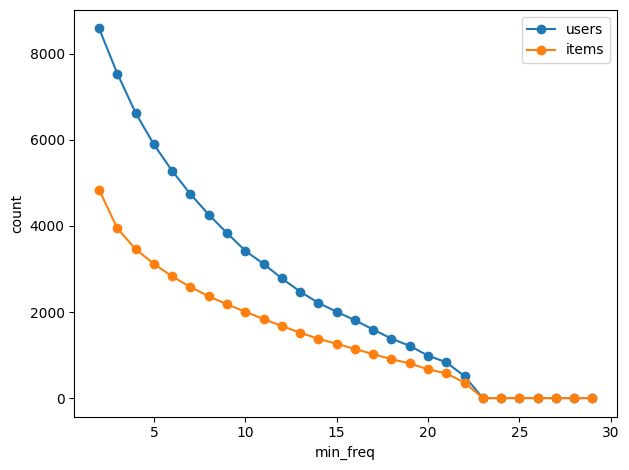

In [127]:
# your code here
freq_values = np.arange(2, 30, 1)
n_users_list = []
n_items_list = []

for freq in freq_values:
    filtered = filter_dataframe(train_df, cols=['user_id', 'item_id'], min_freq=int(freq))
    n_users_list.append(filtered['user_id'].nunique())
    n_items_list.append(filtered['item_id'].nunique())

fig, ax = plt.subplots()
ax.plot(freq_values, n_users_list, marker='o', label='users')
ax.plot(freq_values, n_items_list, marker='o', label='items')
ax.set_xlabel('min_freq')
ax.set_ylabel('count')
ax.legend()
plt.tight_layout()
plt.show()

**Задание №7. EASE**

Реализуйте EASE, постройте рекомендации для юзеров. Сравните все имплементированные ранее метрики качества с `TopPopular` для некоторого набора k. 

Реализацию можно взять из семинара. Можно реализовать по статье https://arxiv.org/pdf/1905.03375.pdf. Можно взять и адаптировать из RecBole https://github.com/RUCAIBox/RecBole.

In [133]:
%%time

# Обучаем конечную модель
# Мы взяли реализацию из RecBole
#
def fit_ease(X, reg_weight=1000):
    G = X.T @ X
    G = G.toarray()
    G += reg_weight * np.eye(G.shape[0])
    P = np.linalg.inv(G)
    B = P / (-np.diag(P))
    np.fill_diagonal(B, 0)
    return B

filtered_train = filter_dataframe(train_df, cols=['user_id', 'item_id'], min_freq=5)
filtered_train, item2id, user2id, id2item, id2user = df_encode(filtered_train.copy())

matrix = sps.coo_matrix(
    (np.ones(filtered_train.shape[0]), (filtered_train['user_id'], filtered_train['item_id'])),
    shape=(len(user2id), len(item2id)),
)

w = fit_ease(matrix)

CPU times: user 25.4 s, sys: 101 ms, total: 25.5 s
Wall time: 1.57 s


Далее, вам надо реализовать функцию получения предсказаний. У вас есть обученная матрица весов, которую можно использовать для получения предсказаний. Для этого нужно построить вектор интеракций пользователя и умножить его на матрицу весов.

In [134]:
def get_preds(x, item2id, id2item, topn=100):

    user_vector = np.zeros(len(item2id))
    for item, _ in x:
        if item in item2id:
            user_vector[item2id[item]] = 1.0

    scores = user_vector @ w

    for item, _ in x:
        if item in item2id:
            scores[item2id[item]] = -np.inf

    top_indices = np.argsort(scores)[::-1][:topn]
    decoded = [id2item[i] for i in top_indices]
    return decoded


joined['ease_preds'] = joined.train_interactions.apply(lambda x: get_preds(x, item2id, id2item))
joined.head()

,user_id,train_interactions,test_interactions,random_recs,toppopular_recs,ease_preds
0,106,"[(9335, 28), (312, 35), (11494, 35), (12965, 5...","[(12908, 159), (2836, 159), (12873, 159), (337...","[6138, 3732, 1029]","[10440, 15297, 9728, 13865, 3734, 4151, 4880, ...","[7571, 16270, 10761, 15266, 11749, 9728, 5411,..."
1,241,"[(5051, 9), (2134, 9), (13913, 112), (6646, 11...","[(6162, 156), (10440, 156), (8986, 156), (1213...","[6138, 3732, 1029]","[10440, 15297, 9728, 13865, 3734, 4151, 4880, ...","[16166, 3182, 7571, 4718, 5411, 13915, 7582, 1..."
2,322,"[(4549, 94), (8419, 94), (14814, 94), (10219, ...","[(4651, 155), (15384, 155), (11099, 157), (633...","[6138, 3732, 1029]","[10440, 15297, 9728, 13865, 3734, 4151, 4880, ...","[3734, 4151, 2657, 8636, 12192, 7829, 4457, 14..."
3,400,"[(169, 144), (11047, 145), (12974, 145), (1399...","[(7793, 153)]","[6138, 3732, 1029]","[10440, 15297, 9728, 13865, 3734, 4151, 4880, ...","[15297, 9728, 13865, 3734, 2657, 4151, 12192, ..."
4,446,"[(13865, 105)]","[(12202, 160), (230, 160)]","[6138, 3732, 1029]","[10440, 15297, 9728, 13865, 3734, 4151, 4880, ...","[9728, 10440, 12995, 3734, 15297, 4880, 8636, ..."


In [135]:
print("EASE:", evaluate_recommender(joined, 'ease_preds'))
print("TopPopular:", evaluate_recommender(joined, 'toppopular_recs'))

EASE: {'map': np.float64(0.09677473028720704), 'mrr': np.float64(0.16805233264262256), 'hr': np.float64(0.6079)}
TopPopular: {'map': np.float64(0.06467026525888132), 'mrr': np.float64(0.11690797619047619), 'hr': np.float64(0.2619)}


Сделайте выводы — какой алгоритм работает лучше?

Наш EASE работает лучше так как основываеться на действиях пользователей, и выдает какие то данные подстроенные 
под пользователей, тем самым мы получаем лучший результат, чем если мы просто выдаем всем одно и тоже 

**Задание №8. Тюнинг**

Переберите различные значения гиперпараметра коэффициента регуляризации у EASE и постройте графики, как в задании №6. Постарайтесь "затюнить" EASE как можно лучше. Возьмите разумное число гиперпараметров - хотя бы штук 20 по логарифмической сетке, либо используйте более хитрые алгоритмы оптимизации. 

100%|██████████| 20/20 [08:47<00:00, 26.37s/it]


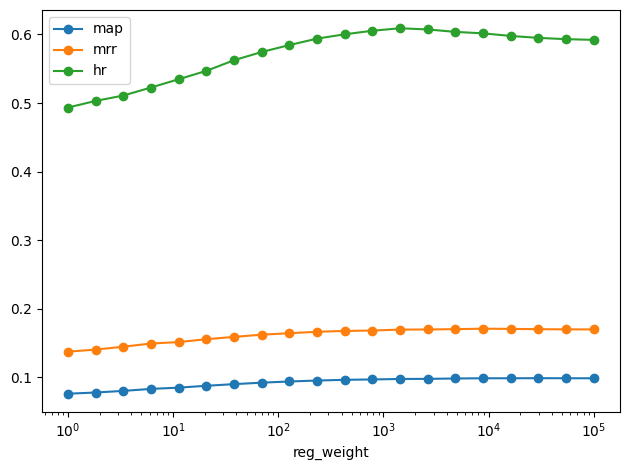

лучший reg_weight: 29763.51
metrics: {'map': np.float64(0.09867175689497322), 'mrr': np.float64(0.17015322027621388), 'hr': np.float64(0.595)}


In [136]:
reg_values = np.logspace(0, 5, 20)

metrics_by_reg = []
for reg in tqdm(reg_values):
    w = fit_ease(matrix, reg_weight=reg)
    joined['ease_preds'] = joined.train_interactions.apply(lambda x: get_preds(x, item2id, id2item))
    metrics_by_reg.append(evaluate_recommender(joined, 'ease_preds'))

fig, ax = plt.subplots()
map_values = [i['map'] for i in metrics_by_reg]
mrr_values = [i['mrr'] for i in metrics_by_reg]
hr_values  = [i['hr'] for i in metrics_by_reg]

ax.plot(reg_values, map_values, label="map", marker='o')
ax.plot(reg_values, mrr_values, label="mrr", marker='o')
ax.plot(reg_values, hr_values,  label="hr",  marker='o')
ax.set_xscale('log')
ax.set_xlabel('reg_weight')
ax.legend()
plt.tight_layout()
plt.show()

best_idx = np.argmax(map_values)
print(f"лучший reg_weight: {reg_values[best_idx]:.2f}")
print(f"metrics: {metrics_by_reg[best_idx]}")

**Задание №9. EASE и topk**

В лекции №2 говорилось, что качество у EASE растет с ослаблением фильтра на число айтемов. В этом задании постройте кривые метрик качества MAP/MRR/HR в зависимости от topk (например, от 1 до 100 с некоторым шагом), где кривая параметризована минимальным требуемым значением встречаемости user/item (из задания №6). Опишите свои выводы.

Важно: в этом задании линии могут быть мало различимыми, поэтому ваша задача для каждой метрики найти нужный масштаб на каких-то конкретных topk, чтобы линии стали визуально отличимы. 

In [139]:
def get_preds_w(x, item2id, id2item, w, topn=100):
    user_vector = np.zeros(len(item2id))
    for item, _ in x:
        if item in item2id:
            user_vector[item2id[item]] = 1.0
    scores = user_vector @ w
    for item, _ in x:
        if item in item2id:
            scores[item2id[item]] = -np.inf
    top_indices = np.argsort(scores)[::-1][:topn]
    decoded = [id2item[i] for i in top_indices]
    return decoded

In [140]:
min_freqs = [3, 5, 10, 20]
k_values = np.arange(1, 101, 5)

results_by_freq = {}
for freq in tqdm(min_freqs):
    ft = filter_dataframe(train_df, cols=['user_id', 'item_id'], min_freq=freq)
    ft, i2id, u2id, id2i, id2u = df_encode(ft.copy())
    
    m = sps.coo_matrix(
        (np.ones(ft.shape[0]), (ft['user_id'], ft['item_id'])),
        shape=(len(u2id), len(i2id)),
    )
    w_temp = fit_ease(m)
    
    joined['ease_preds'] = joined.train_interactions.apply(
        lambda x, i2id=i2id, id2i=id2i, w=w_temp: get_preds_w(x, i2id, id2i, w)
    )
    
    metrics_by_k = []
    for k in k_values:
        metrics_by_k.append(evaluate_recommender(joined, 'ease_preds', k=int(k)))
    results_by_freq[freq] = metrics_by_k

100%|██████████| 4/4 [02:37<00:00, 39.49s/it]


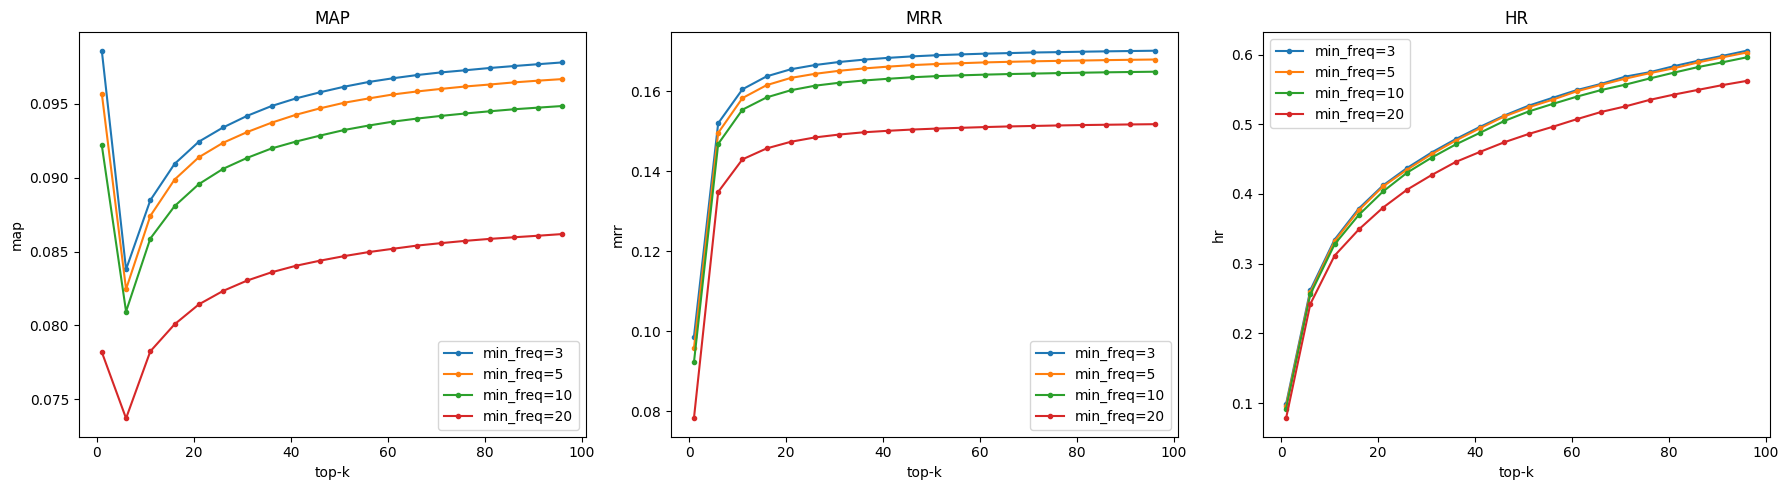

In [143]:
metric_names = ['map', 'mrr', 'hr']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric in zip(axes, metric_names):
    for freq in min_freqs:
        values = [m[metric] for m in results_by_freq[freq]]
        ax.plot(k_values, values, label=f'min_freq={freq}', marker='o', markersize=3)
    ax.set_xlabel('top-k')
    ax.set_ylabel(metric)
    ax.set_title(metric.upper())
    ax.legend()

plt.tight_layout()
plt.show()

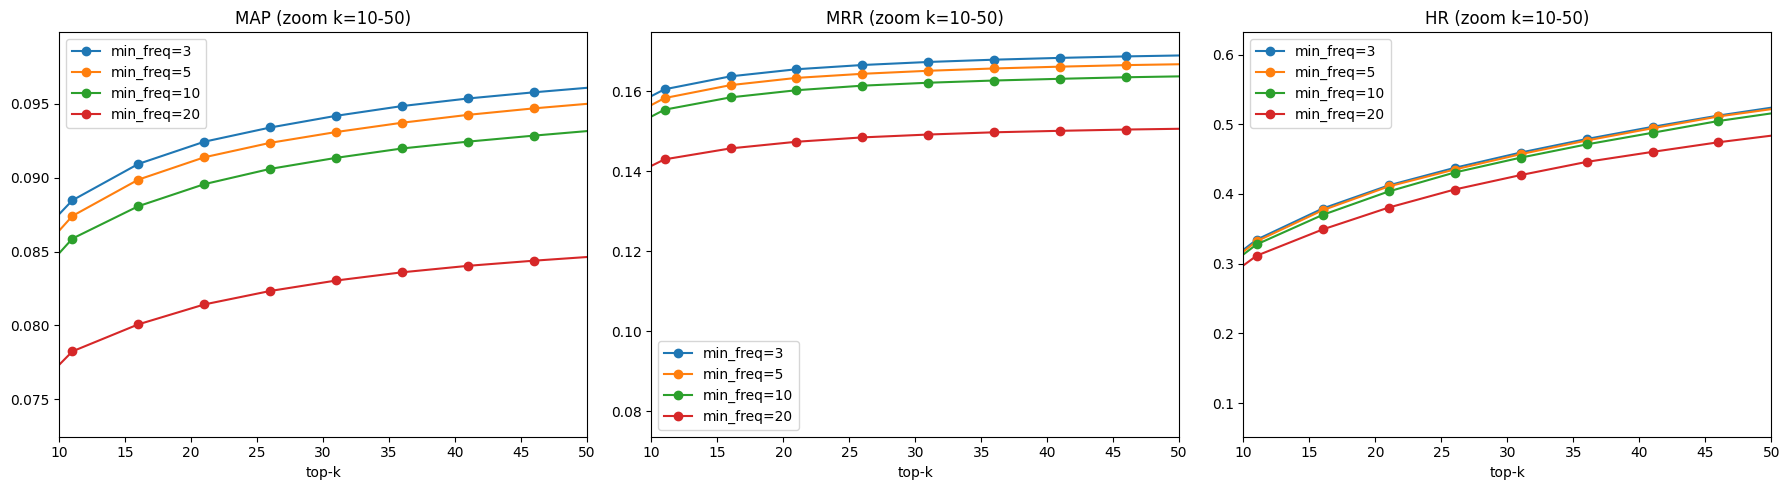

In [142]:
metric_names = ['map', 'mrr', 'hr']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
zoom_k = (10, 50)

for ax, metric in zip(axes, metric_names):
    for freq in min_freqs:
        values = [m[metric] for m in results_by_freq[freq]]
        ax.plot(k_values, values, label=f'min_freq={freq}', marker='o')
    ax.set_xlim(zoom_k)
    ax.set_xlabel('top-k')
    ax.set_title(f'{metric.upper()} (zoom k={zoom_k[0]}-{zoom_k[1]})')
    ax.legend()

plt.tight_layout()
plt.show()

Что вы можете сказать на основе полученных графиков? Соответствуют ли они вашим ожиданиям?

**Ответ:**

**Задание №10. Интерпретируемые рекомендации**

Используйте выученную матрицу весов для item2item рекомендаций. Приведите 10 примеров топ-5 рекомендаций от EASE к сэмплируемым айтемам. Используйте названия фильмов вместо id при выводе рекомендаций. 

In [145]:
sample_items = np.random.choice(list(item2id.keys()), size=10, replace=False)

for orig_item_id in sample_items:
    idx = item2id[orig_item_id]    
    scores = w[idx].copy()
    scores[idx] = -np.inf
    
    top5_indices = np.argsort(scores)[::-1][:5]
    top5_items = [id2item[i] for i in top5_indices]
    
    source_name = items.loc[items.item_id == orig_item_id, 'title'].values
    source_name = source_name[0] if len(source_name) > 0 else f'id={orig_item_id}'
    
    rec_names = []
    for item_id in top5_items:
        name = items.loc[items.item_id == item_id, 'title'].values
        rec_names.append(name[0] if len(name) > 0 else f'id={item_id}')
    
    print(f"\n{source_name} ")
    for i, name in enumerate(rec_names, 1):
        print(f"  {i}. {name}")


Книга Илая 
  1. Гнев человеческий
  2. Прабабушка легкого поведения
  3. Хрустальный
  4. Веном
  5. Дочь волка

Голяк 
  1. Гнев человеческий
  2. Хрустальный
  3. Афера
  4. Прабабушка легкого поведения
  5. Маша

Как женить холостяка 
  1. Клиника счастья
  2. Девятаев
  3. Хрустальный
  4. Гнев человеческий
  5. Экстрасенсы

Девушка грез 
  1. Гнев человеческий
  2. Окей, Лекси!
  3. Цвет из иных миров
  4. 2067: Петля времени
  5. Прабабушка легкого поведения

Зачем мы женимся? 
  1. Клиника счастья
  2. Королева
  3. Дублёрша
  4. Простые сложности
  5. Аферистка

13 район: Ультиматум 
  1. 13-й район: Кирпичные особняки
  2. Балканский рубеж
  3. Афера
  4. Девятаев
  5. Гнев человеческий

Дефолт 
  1. Хрустальный
  2. Поиск
  3. Сахаров. Две жизни
  4. Гнев человеческий
  5. Игры судьбы

Война 
  1. Девятаев
  2. Прабабушка легкого поведения
  3. Гнев человеческий
  4. Хрустальный
  5. Братство

Король Артур 
  1. Девятаев
  2. Прабабушка легкого поведения
  3. Гнев человечес